In [2]:
%reload_ext autoreload
%autoreload 2

In [3]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from flax import nnx

In [55]:
# MNIST data
from datasets import load_dataset
import numpy as np

dataset = load_dataset('mnist', keep_in_memory=True)

dataset.set_format(type='numpy', columns=['image'])


In [145]:
import scipy


train_data = dataset["train"]   

def train_data_generator(batch_size=128):
    key = jax.random.key(0)
    while True:
        key,subkey, subkey2 = jax.random.split(key,3)
        idx = np.random.randint(0,len(train_data), size=batch_size)
        
        xs_batch = train_data[idx]["image"]/256
        #Rotate a bit
        xs_batch = scipy.ndimage.rotate(xs_batch, np.random.uniform()*10, axes=(1,2), reshape=False)
        
        # Quantize
        xs_batch = jnp.array(train_data[idx]["image"]/256, dtype=jnp.float32).reshape(batch_size, 28,28,1)
        xs_batch += jax.random.uniform(subkey2, xs_batch.shape)/255 # Uniform dequantization
        # Rescale to [-1,1]
        xs_batch = jnp.nan_to_num(xs_batch)
        
    
        
        yield xs_batch.reshape(batch_size, -1, 1)

datagenerator = train_data_generator()

In [57]:
from probjax.nn.nets.unets import UNet

In [159]:
from probjax.nn.nets.transformer import PosEmbed, Transformer
from probjax.nn.bijective import rational_quadratic_spline,learnable_mixture_cdf, piecwise_linear_spline
from probjax.core import inverse_and_logabsdet
from functools import partial

NUM_BINS=30

cdf_model = partial(piecwise_linear_spline,range_min_x=0., range_max_x=1., range_min_y= 0., range_max_y=1., bounded=True)
cdf_model = partial(rational_quadratic_spline,range_min_x=0., range_max_x=1., range_min_y= 0., range_max_y=1., bounded=True, min_bin_size=1e-3)

class Model(nnx.Module, experimental_pytree=True):

    num_heads: int = 4
    num_layers: int = 8
    dim: int
    widening_factor: int = 2
    attn_size: int = 32
    num_params:int =  3*NUM_BINS 

    def __init__(self, dim,rngs, dropout_rate=None):
        self.embed = nnx.Linear(1, dim, rngs=rngs)
        self.pos_embed = PosEmbed(dim,rngs=rngs)
        self.transformer = Transformer(dim, self.num_heads,self.num_heads,self.attn_size, widening_factor=self.widening_factor,rngs=rngs, dropout_rate=dropout_rate)
        self.output = nnx.Linear(dim, self.num_params, rngs=rngs, kernel_init=nnx.initializers.zeros)
        self.start_token = nnx.Param(jnp.zeros((1,dim)))

    def __call__(self, x, decode=False, deterministic=False):
        x = self.embed(x)
        x = self.pos_embed(x)
        # Autoregressive mask 
        start_token = self.start_token.value
        start_token = jnp.repeat(start_token[None,...], x.shape[0], axis=0)
        x = jnp.concatenate([start_token, x], axis=1)
        mask = jnp.tril(jnp.ones((x.shape[-2], x.shape[-2])))
        x = self.transformer(x, mask=mask, deterministic=deterministic, decode=decode)
        params = self.output(x)
        return params[..., :-1, :]
    
    
    def loss(self, params, x):
        nnx.update(self, params)
        def log_prob(params, x):
            _cdf = partial(cdf_model, params)
            x = jnp.clip(x, 0., 1.)
            u, logabsdet = inverse_and_logabsdet(_cdf)(x)
            log_prob0 = jax.scipy.stats.uniform.logpdf(u).sum(axis=-1)
            return logabsdet + log_prob0
        
        params = self(x)
        loss = - jax.vmap(jax.vmap(log_prob))(params, x)
        loss = jnp.nan_to_num(loss)
        return jnp.mean(loss)
    
    def transform(self, x):
        params = self(x)
        icdf = lambda p,x: inverse_and_logabsdet(partial(cdf_model, p))(x)[0]
        return jax.vmap(jax.vmap(icdf))(params, x)
            
        
model = Model(512, rngs=nnx.Rngs(0))
params = nnx.state(model, nnx.Param)

512


In [160]:
# Visualize initial model denoising
x = next(datagenerator)

y = model.loss(params,x)


(128, 785, 512)
(128, 785, 512)
(128, 785, 512)
(128, 785, 512)


In [161]:
def loss_fn(params, x):
    return model.loss(params, x)


In [163]:
from functools import partial
import optax

schedule = optax.cosine_onecycle_schedule(50*200, 5e-4)
opt = optax.chain(optax.adaptive_grad_clip(10.), optax.adamw(schedule))
params_per_device = jax.tree_util.tree_map(
    lambda p: jnp.stack([p] * jax.local_device_count(), axis=0), 
    params
)
opt_state = jax.vmap(opt.init)(params_per_device)

@partial(jax.pmap, axis_name='batch')
def update(params, opt_state, x):
    loss, grads = jax.value_and_grad(loss_fn)(params, x)
    grads = jax.tree_map(lambda x: jnp.nan_to_num(x), grads)

    # Average across all replicas on the 'batch' axis
    loss = jax.lax.pmean(loss, axis_name='batch')
    grads = jax.lax.pmean(grads, axis_name='batch')

    updates, opt_state = opt.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    params = jax.tree_map(lambda x: jnp.nan_to_num(x), params)

    return params, opt_state, loss

def train_step(params, opt_state, xs):
    # Reshape xs to split across devices
    xs_split = jnp.reshape(xs, (jax.local_device_count(), -1, *xs.shape[1:]))

    params, opt_state, losses = update(params, opt_state, xs_split)
    return params, opt_state, jnp.mean(losses)


In [164]:
key = jax.random.key(1)

In [ ]:
# Example training iteration
for i in range(50):
    l = 0.
    for j in range(200): 
        key, key_data, key_loss = jax.random.split(key, 3)
        xs = next(datagenerator)
        params_per_device, opt_state, loss = train_step(params_per_device, opt_state, xs)
        l += loss
    print(l/200)

(128, 785, 512)
(128, 785, 512)
(128, 785, 512)
(128, 785, 512)
-2.2518196
-3.8479192
-4.327065
-4.4557676
-4.4606113
-4.4523335
-4.515224
-4.5611677
-4.5935373
-4.6196804
-4.64698
-4.6571608
-4.6908336
-4.661502
-4.703993
-4.719688
-4.7217226
-4.7023416
-4.738332
-4.6352854
-4.6979623


In [149]:
params = jax.tree_map(lambda x: x[0], params_per_device)
nnx.update(model, params)

In [150]:
u = model.transform(x)

u.min(), u.max()

(128, 785, 512)
(128, 785, 512)
(128, 785, 512)
(128, 785, 512)


(Array(0., dtype=float32), Array(1., dtype=float32))

In [151]:
spline_params = model(x)

(128, 785, 512)
(128, 785, 512)
(128, 785, 512)
(128, 785, 512)


In [152]:
from probjax.core import inverse

custom_inverse_call_p [True, False] [True]


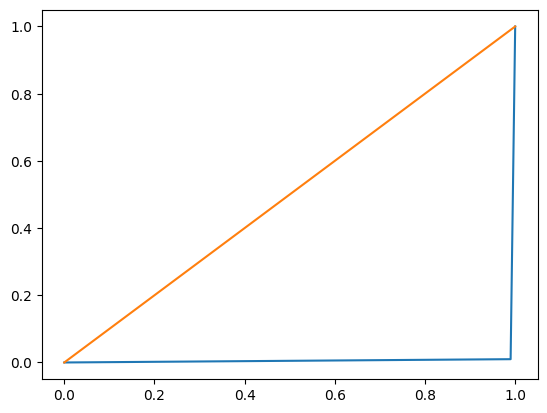

In [153]:
spine_p = spline_params[0,100,:]
cdf = partial(cdf_model, spine_p)
icdf = lambda p: inverse(cdf)(p)
ts = jnp.linspace(0,1,100)
ys = jax.vmap(cdf)(ts)
plt.plot(ts, ys)
ts_rec = jax.vmap(icdf)(ys)
plt.plot(ts, ts_rec)


In [154]:

def naive_autoregressive_decoding(key, T=784):
    x = jax.random.uniform(key,(1, T,1), dtype=jnp.float32)
    def scan_fn(carry, k):
        x, i = carry
        params = model(x)
        p_i = params[0,i]
        u_i = x[0, i]
        cdf = partial(cdf_model,p_i)
        icdf = inverse_and_logabsdet(cdf)
        x_i = icdf(u_i)[0]
        x = x.at[0, i].set(x_i)
        return (x, i+1), None
    keys = jax.random.split(key, (T,))
    x, _ = jax.lax.scan(scan_fn, (x, 0), keys)

    return x[0].squeeze(0)

In [155]:
keys = jax.random.split(jax.random.key(0), (100,))

In [156]:
samples = jax.vmap(naive_autoregressive_decoding)(keys)

(1, 785, 512)
(1, 785, 512)
(1, 785, 512)
(1, 785, 512)


In [157]:
img = samples.reshape(10, 10, 28, 28).transpose(0, 2, 1, 3).reshape(10*28, 10*28)

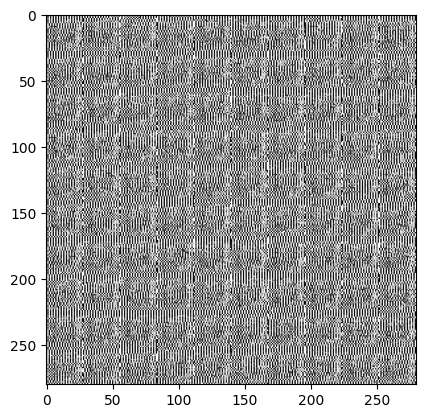

In [158]:
plt.imshow(img, cmap="gray")